## Importamos las librerias

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from dotenv import load_dotenv



## Obtenemos las credenciales de spotify (lectura de variables de entorno del archivo env)

In [7]:
load_dotenv()

client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")





## Realizamos la conexion con Spotify utilizando las credenciales

In [8]:
auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
spotify = spotipy.Spotify(auth_manager=auth_manager)

## Obtenemos el top 10 de las canciones del artista, pasamos los datos a un df y filtramos por las columnas que queremos (name,popularity,duration)

In [ ]:
artist_id = 'spotify:artist:5ZqnEfVdEGmoPxtELhN7ai'

top_songs = spotify.artist_top_tracks(artist_id)['tracks']

top_songs_df = pd.DataFrame(top_songs)
top_songs_df['duration_min'] = top_songs_df['duration_ms'] / 1000 / 60
top_songs_df_filter = top_songs_df[['name', 'popularity', 'duration_min']]

top_songs_df_filter


,name,popularity,duration_min
0,Como Camarón,71,3.367100
1,Por la Raja de Tu Falda,69,3.380433
2,Diablo,67,2.744483
3,Tu Calorro,69,3.177100
4,Vino Tinto,67,3.309333
5,Paseo,65,3.607333
6,El Run Run (with Rosario),64,3.422217
7,Cacho a Cacho,63,2.479100
8,Camiseta de Rokanrol,63,3.830533
9,Vacaciones,63,3.206433


## Ordenamos las canciones por orden creciente de popularidad y mostramos las 3 más populares

In [10]:
growing_population = top_songs_df_filter.sort_values('popularity')
growing_population.tail(3)

,name,popularity,duration_min
1,Por la Raja de Tu Falda,69,3.380433
3,Tu Calorro,69,3.177100
0,Como Camarón,71,3.367100


## Analizamos los datos en una grafica, como podemos ver no hay mucha relacion de la duracion de una cancion con su popularidad, ya que tenemos canciones de tiempo corto, medio y largo poco valoradas, por lo que los datos no tienen una relacion lineal

Text(0, 0.5, 'Popularity')

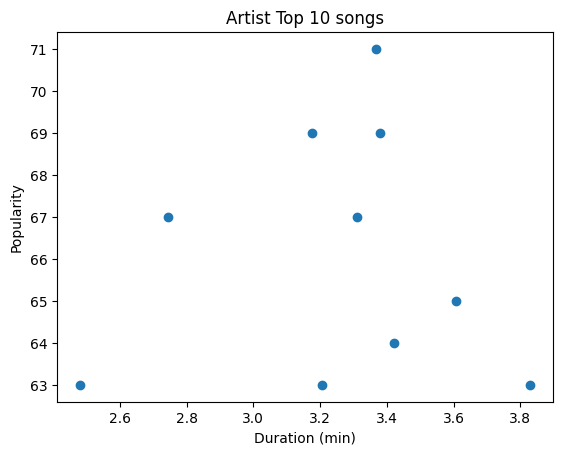

In [12]:
plt.scatter(top_songs_df_filter['duration_min'], top_songs_df_filter['popularity'])

plt.title('Artist Top 10 songs')
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')